In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
# Simulate application-like features
df['ApplicationSpeed'] = np.random.randint(1, 10, size=len(df))  # fast submissions
df['DuplicateFlag'] = df.duplicated().astype(int)  # duplicates
df['InconsistencyScore'] = abs(df['JobInvolvement'] - df['PerformanceRating'])

In [8]:
features = ['ApplicationSpeed', 'DuplicateFlag', 'InconsistencyScore']
X = df[features]

In [10]:
model = IsolationForest(contamination=0.05, random_state=42)
df['Anomaly_IF'] = model.fit_predict(X)

In [12]:
df['Anomaly_IF'] = df['Anomaly_IF'].map({
    1: 'Normal',
    -1: 'Anomaly'
})

In [14]:
kmeans = KMeans(n_clusters=2, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

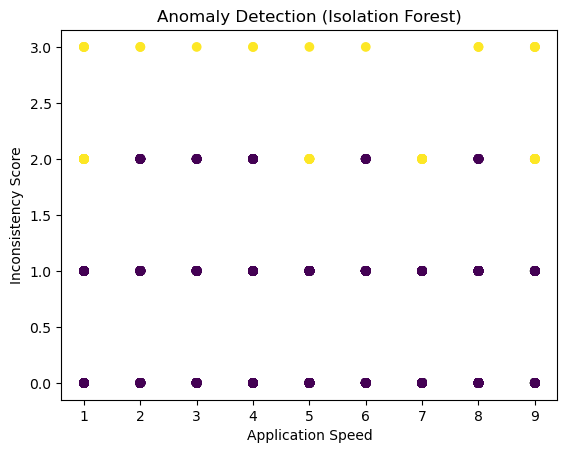

In [16]:
plt.figure()
plt.scatter(df['ApplicationSpeed'], df['InconsistencyScore'],
            c=(df['Anomaly_IF'] == 'Anomaly'))
plt.xlabel("Application Speed")
plt.ylabel("Inconsistency Score")
plt.title("Anomaly Detection (Isolation Forest)")
plt.show()

In [18]:
anomalies = df[df['Anomaly_IF'] == 'Anomaly']
print(anomalies.head())

     Age Attrition     BusinessTravel  DailyRate              Department  \
26    32       Yes  Travel_Frequently       1125  Research & Development   
42    26       Yes      Travel_Rarely       1357  Research & Development   
111   34       Yes  Travel_Frequently        658  Research & Development   
120   30        No  Travel_Frequently       1312  Research & Development   
124   31       Yes      Travel_Rarely        249                   Sales   

     DistanceFromHome  Education EducationField  EmployeeCount  \
26                 16          1  Life Sciences              1   
42                 25          3  Life Sciences              1   
111                 7          3  Life Sciences              1   
120                23          3  Life Sciences              1   
124                 6          4  Life Sciences              1   

     EmployeeNumber  ...  WorkLifeBalance YearsAtCompany  YearsInCurrentRole  \
26               33  ...                3             10          

In [26]:
for i, row in anomalies.iterrows():
    print(f" Alert: Suspicious application detected at index {i}")

 Alert: Suspicious application detected at index 26
 Alert: Suspicious application detected at index 42
 Alert: Suspicious application detected at index 111
 Alert: Suspicious application detected at index 120
 Alert: Suspicious application detected at index 124
 Alert: Suspicious application detected at index 132
 Alert: Suspicious application detected at index 144
 Alert: Suspicious application detected at index 157
 Alert: Suspicious application detected at index 171
 Alert: Suspicious application detected at index 177
 Alert: Suspicious application detected at index 224
 Alert: Suspicious application detected at index 263
 Alert: Suspicious application detected at index 308
 Alert: Suspicious application detected at index 323
 Alert: Suspicious application detected at index 325
 Alert: Suspicious application detected at index 335
 Alert: Suspicious application detected at index 336
 Alert: Suspicious application detected at index 391
 Alert: Suspicious application detected at index

In [22]:
print(df['Anomaly_IF'].value_counts())

Anomaly_IF
Normal     1408
Anomaly      62
Name: count, dtype: int64


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(contamination=0.05)
df['Anomaly_IF'] = model.fit_predict(X_scaled)